In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import numpy as np

In [2]:
data = pd.read_csv("/Users/anshumaansoni/PycharmProjects/battery-life-predictor/new_code/DATASET.csv")

In [3]:
model = joblib.load("../models/battery_random_forest_model.joblib")

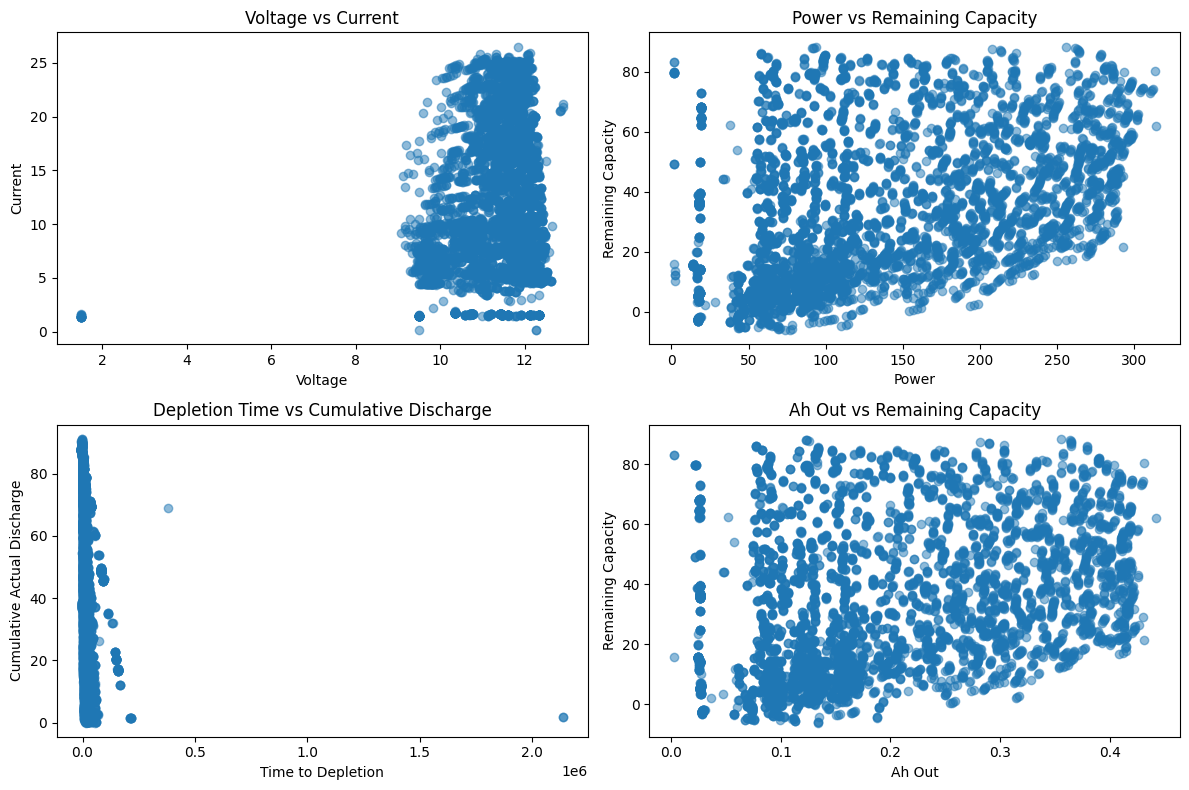

In [4]:
plt.figure(figsize=(12, 8))

# Plot Voltage vs Current
plt.subplot(2, 2, 1)
plt.scatter(data['Voltage'], data['Current'], alpha=0.5)
plt.xlabel('Voltage')
plt.ylabel('Current')
plt.title('Voltage vs Current')

# Plot Power vs Remaining Capacity
plt.subplot(2, 2, 2)
plt.scatter(data['Power'], data['Remaining Capacity'], alpha=0.5)
plt.xlabel('Power')
plt.ylabel('Remaining Capacity')
plt.title('Power vs Remaining Capacity')

# Plot Time to Depletion vs Cumulative Actual Disch Ah
plt.subplot(2, 2, 3)
plt.scatter(data['Time to Depletion'], data['Cumulative Actual Disch Ah'], alpha=0.5)
plt.xlabel('Time to Depletion')
plt.ylabel('Cumulative Actual Discharge')
plt.title('Depletion Time vs Cumulative Discharge')

# Plot Ah Out vs Remaining Capacity
plt.subplot(2, 2, 4)
plt.scatter(data['Ah Out'], data['Remaining Capacity'], alpha=0.5)
plt.xlabel('Ah Out')
plt.ylabel('Remaining Capacity')
plt.title('Ah Out vs Remaining Capacity')

plt.tight_layout()
plt.show()


In [5]:
data['prediction'] = None
pred = []

In [6]:
data.shape

(5437, 11)

In [7]:
for _, i in data.iterrows():
    x = pd.DataFrame(i).T
x


,Current,Voltage,Ah Out,Cumulative Actual Disch Ah,Power,Remaining Capacity,Time to Depletion,type,capacity,charged,prediction
5436,6.04,9.83,0.100667,76.240333,59.3732,3.759667,2240.860927,tn1,85.0,80.0,None


In [8]:
import threading

In [9]:
def predictor(pred,model,data):
    for index,i in data.iterrows():
        x = pd.DataFrame(i).T
        pred[index] = model.predict(x)

In [10]:
pred = {}

t1 = threading.Thread(target=predictor, args=(pred, model, data.iloc[:1000, :]))
t2 = threading.Thread(target=predictor, args=(pred, model, data.iloc[1000:2000, :]))
t3 = threading.Thread(target=predictor, args=(pred, model, data.iloc[2000:3000, :]))
t4 = threading.Thread(target=predictor, args=(pred, model, data.iloc[3000:4000, :]))
t5 = threading.Thread(target=predictor, args=(pred, model, data.iloc[4000:5000, :]))
t6 = threading.Thread(target=predictor, args=(pred, model, data.iloc[5000:5437, :]))

t1.start()
t2.start()
t3.start()
t4.start()
t5.start()
t6.start()

t1.join()
t2.join()
t3.join()
t4.join()
t5.join()
t6.join()


In [16]:
pred

{2000: np.float64(16356.443810032257),
 5000: np.float64(1808.4382574861208),
 4000: np.float64(10306.210305904058),
 0: np.float64(10395.389494381656),
 1000: np.float64(10487.83602086325),
 3000: np.float64(9011.29128024627),
 5001: np.float64(1741.4900273412102),
 2001: np.float64(25877.952697010765),
 1001: np.float64(10504.279249800558),
 4001: np.float64(10216.490896358277),
 3001: np.float64(8875.030583875077),
 1: np.float64(10383.381179349644),
 5002: np.float64(1698.926669841226),
 2002: np.float64(25861.180795245968),
 1002: np.float64(10501.677145102569),
 2: np.float64(10391.152743161447),
 4002: np.float64(10182.395964280784),
 3002: np.float64(8846.753787690996),
 5003: np.float64(1643.4721471734777),
 1003: np.float64(10514.65951582199),
 2003: np.float64(25784.893017285805),
 4003: np.float64(10175.803198192547),
 3: np.float64(13311.084442609628),
 5004: np.float64(1592.609416135518),
 3003: np.float64(8810.085109030095),
 2004: np.float64(25747.77634355115),
 1004: n

In [18]:
data['prediction'] = pred

In [19]:
data

,Current,Voltage,Ah Out,Cumulative Actual Disch Ah,Power,Remaining Capacity,Time to Depletion,type,capacity,charged,prediction
0,9.36,11.84,0.156000,0.156000,110.8224,26.844000,10324.615385,b2,88.81,27.0,10395.389494
1,9.34,11.84,0.155667,0.311667,110.5856,26.688333,10286.723769,b2,88.81,27.0,10383.381179
2,9.34,11.83,0.155667,0.467333,110.4922,26.532667,10226.723769,b2,88.81,27.0,10391.152743
3,7.14,11.88,0.119000,0.586333,84.8232,26.413667,13317.815126,b2,88.81,27.0,13311.084443
4,7.13,11.88,0.118833,0.705167,84.7044,26.294833,13276.493689,b2,88.81,27.0,13279.109429
...,...,...,...,...,...,...,...,...,...,...,...
5432,6.69,9.74,0.111500,75.816500,65.1606,4.183500,2251.210762,tn1,85.00,80.0,2234.411705
5433,6.69,9.75,0.111500,75.928000,65.2275,4.072000,2191.210762,tn1,85.00,80.0,2181.857911
5434,6.69,9.75,0.111500,76.039500,65.2275,3.960500,2131.210762,tn1,85.00,80.0,2137.972846
5435,6.01,9.83,0.100167,76.139667,59.0783,3.860333,2312.346090,tn1,85.00,80.0,2243.325558


In [20]:
with open("../new_code/DATASET2.csv", "w") as f:
    f.write(
        data.to_csv(index=False)
    )